In [17]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
# Set base directory
dir_path = "/global/scratch/users/yougsanghvi"

# Construct full path to ERA5 CSV
era5_filepath = os.path.join(
    dir_path,
    "data", "merged", "USA",
    "USA_adm2_1968_2004_monthly.dta"
)

# Load the ERA5 dataset
era5_df = pd.read_stata(era5_filepath)

# Define paths for usa county shapefile
usa_county_dir = os.path.join(dir_path, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

era5full_filepath = os.path.join(
    dir_path,
    "data", "climatedata", "USA",
    "usa_area_era5_temp_average_1968_2004_polynomial_5_area_crop_weights.csv"
)

# Load the ERA5 dataset
era5full_df = pd.read_csv(era5full_filepath)

# Loading in county shapefile
usa_counties = gpd.read_file(usa_county_path)


In [3]:

# Preview the data
print(era5full_df.head())

   year     month  poly_id     order_1       order_2        order_3  \
0  1968  month_01    66010  809.525712  21148.066612  552689.640160   
1  1968  month_02    66010  745.377742  19162.975018  492783.926998   
2  1968  month_03    66010  810.887864  21213.814140  555054.625154   
3  1968  month_04    66010  788.264914  20714.948921  544447.993773   
4  1968  month_05    66010  832.136596  22344.346350  600179.878807   

        order_4       order_5  
0  1.444981e+07  3.779311e+08  
1  1.267524e+07  3.261076e+08  
2  1.452486e+07  3.801433e+08  
3  1.431166e+07  3.762570e+08  
4  1.612637e+07  4.334445e+08  


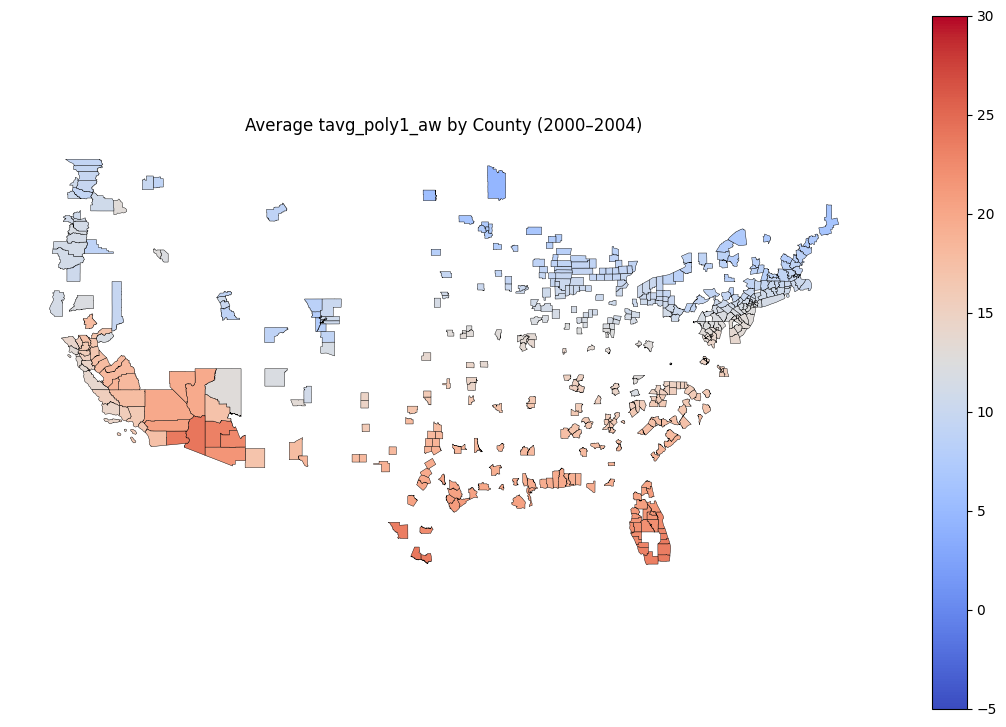

In [29]:
# 1. Filter era5_df to desired period (e.g., 2000–2004)
era5_filtered = era5_df[(era5_df['year'] >= 2000) & (era5_df['year'] <= 2004)]
era5full_filtered = era5full_df[(era5full_df['year'] >= 2000) & (era5full_df['year'] <= 2004)]

# 2. Aggregate average tavg_poly1_aw by county (fips)
avg_tavg_poly1 = era5_filtered.groupby('fips')['tavg_poly1_aw'].mean().reset_index()

# 3. Prepare shapefile: convert GEOID to int
usa_counties['GEOID'] = usa_counties['GEOID'].astype(int)

# 4. Merge shapefile with data
merged = usa_counties.merge(avg_tavg_poly1, left_on='GEOID', right_on='fips', how='left')

# 5. Crop to mainland USA bounding box
bbox = (-125, 24, -66, 50)
merged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# 6. Plot
fig, ax = plt.subplots(figsize=(14, 9))
merged_mainland.plot(
    column='tavg_poly1_aw',
    cmap='coolwarm',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax,
    vmin = -5,
    vmax = 30
)
ax.set_title('Average tavg_poly1_aw by County (2000–2004)')
ax.axis('off')
plt.show()


In [5]:
era5full_filtered

,year,month,poly_id,order_1,order_2,order_3,order_4,order_5
1239552,2000,month_01,66010,824.063503,21914.412624,582997.955191,1.551566e+07,4.130827e+08
1239553,2000,month_02,66010,776.330163,20786.377729,556665.570920,1.491051e+07,3.994590e+08
1239554,2000,month_03,66010,835.801745,22537.678005,607825.276604,1.639500e+07,4.422894e+08
1239555,2000,month_04,66010,820.620232,22448.910401,614158.416733,1.680342e+07,4.597768e+08
1239556,2000,month_05,66010,844.319105,23005.267664,627081.626868,1.710005e+07,4.664950e+08
...,...,...,...,...,...,...,...,...
1433227,2004,month_08,78020,854.386327,23552.728446,649413.658565,1.790993e+07,4.940346e+08
1433228,2004,month_09,78020,815.764846,22192.504189,604007.843506,1.644641e+07,4.480115e+08
1433229,2004,month_10,78020,834.427332,22468.910965,605261.471726,1.631069e+07,4.397144e+08
1433230,2004,month_11,78020,779.677264,20269.333771,527104.891361,1.371165e+07,3.567952e+08


In [6]:


# Step 1: Create a safe copy of the data
era5full_filtered_copy = era5full_filtered.copy()

# Step 2: Divide order_1 by 30
era5full_filtered_copy['order_1_div30'] = era5full_filtered_copy['order_1'] / 30


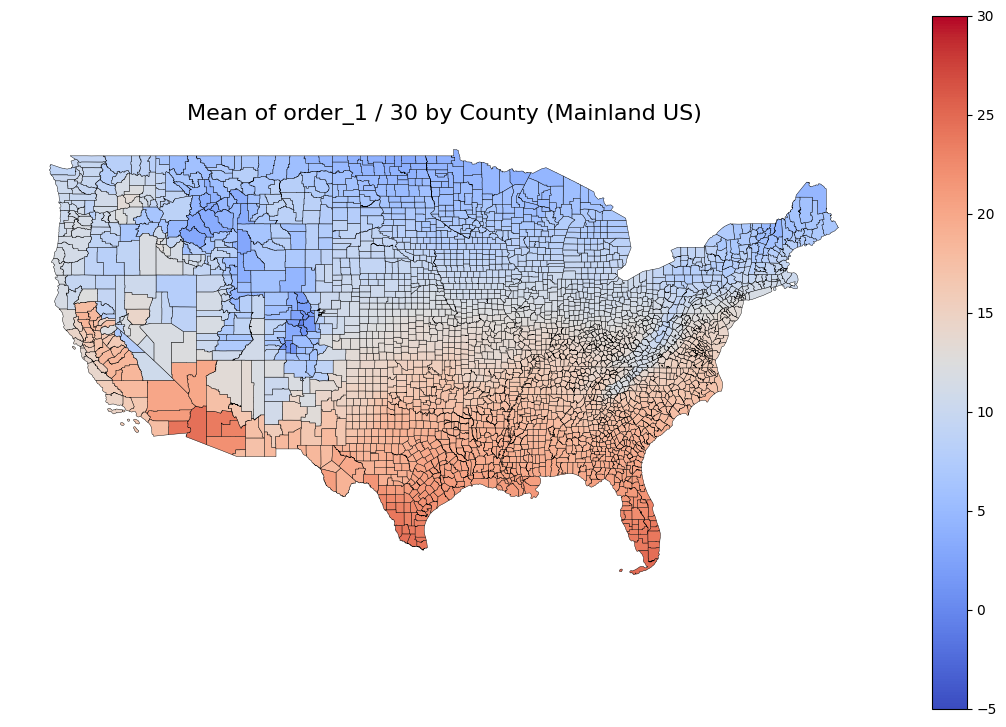

In [22]:

# Step 3: Compute the average (mean) of order_1_div30 by county
order_avg = era5full_filtered_copy.groupby('poly_id')['order_1_div30'].mean().reset_index()

# Step 4: Convert GEOID to int in the county shapefile
usa_counties['GEOID'] = usa_counties['GEOID'].astype(int)

# Step 5: Merge the shapefile with the order_1 data
merged = usa_counties.merge(order_avg, left_on='GEOID', right_on='poly_id', how='left')

# Step 6: Crop to mainland USA using bounding box
bbox = (-125, 24, -66, 50)
merged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Step 7: Plot
fig, ax = plt.subplots(figsize=(14, 9))
merged_mainland.plot(
    column='order_1_div30',
    cmap='coolwarm',
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    ax=ax,
    vmin = -5,
    vmax = 30
)
ax.set_title('Mean of order_1 / 30 by County (Mainland US)', fontsize=16)
ax.axis('off')
plt.show()


In [9]:
import xarray as xr
import os
import matplotlib.pyplot as plt

# Step 1: Define path and years
data_dir = "/global/scratch/users/yougsanghvi/era5_daily_by_year"
years = range(2000, 2005)  # 2000–2004

# Step 2: Read and concatenate NetCDFs along time dimension
datasets = []
for year in years:
    file_path = os.path.join(data_dir, f"era5_daily_mean_{year}.nc")
    ds = xr.open_dataset(file_path)
    datasets.append(ds)

# Combine into one dataset along time
combined_ds = xr.concat(datasets, dim="time")

# Step 3: Average across time (days) to get mean for each grid cell
mean_ds = combined_ds.mean(dim="time")

# Step 4: Plot temperature (assuming variable is named 't2m' for 2m temperature)
# If variable name is different (e.g. 'temperature'), update below

temp_var = 't2m' if 't2m' in mean_ds.data_vars else list(mean_ds.data_vars.keys())[0]

# Convert from Kelvin to Celsius (optional)
mean_temp_celsius = mean_ds[temp_var] - 273.15



/tmp/ipykernel_144010/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_144010/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_144010/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_144010/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta 

In [11]:
mean_temp_celsius

<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)> Size: 4MB
array([[-14.073456, -14.073456, -14.073456, ..., -14.073456, -14.073456,
        -14.073456],
       [-14.105133, -14.104797, -14.104248, ..., -14.106567, -14.106201,
        -14.105652],
       [-14.069977, -14.068695, -14.067444, ..., -14.073212, -14.072205,
        -14.071045],
       ...,
       [-45.304   , -45.303574, -45.302124, ..., -45.306046, -45.30484 ,
        -45.304214],
       [-45.39212 , -45.39119 , -45.390244, ..., -45.39386 , -45.39319 ,
        -45.39267 ],
       [-45.814163, -45.814163, -45.814163, ..., -45.814163, -45.814163,
        -45.814163]], shape=(721, 1440), dtype=float32)
Coordinates:
    number     int64 8B 0
    step       timedelta64[ns] 8B 00:00:00
    surface    float64 8B 0.0
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [15]:
usa_counties

,ID_1,ID_2,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,ID_0,geometry
0,01,001,00161526,1001,Autauga,Autauga County,06,H1,G4020,None,33860,None,A,1539609015,25749942,+32.5322367,-086.6464395,244,"POLYGON ((-86.9031 32.54063, -86.90313 32.5410..."
1,01,003,00161527,1003,Baldwin,Baldwin County,06,H1,G4020,380,19300,None,A,4117584019,1133130502,+30.6592183,-087.7460666,244,"POLYGON ((-87.99068 30.55549, -87.99051 30.560..."
2,01,005,00161528,1005,Barbour,Barbour County,06,H1,G4020,None,21640,None,A,2291818680,50864677,+31.8702531,-085.4051035,244,"POLYGON ((-85.42982 32.04598, -85.42985 32.046..."
3,01,007,00161529,1007,Bibb,Bibb County,06,H1,G4020,142,13820,None,A,1612481559,9287974,+33.0158929,-087.1271475,244,"POLYGON ((-87.31226 33.08622, -87.31218 33.087..."
4,01,009,00161530,1009,Blount,Blount County,06,H1,G4020,142,13820,None,A,1670041875,15077458,+33.9773575,-086.5664400,244,"POLYGON ((-86.74919 33.9976, -86.74902 33.9975..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3223,72,151,01804556,72151,Yabucoa,Yabucoa Municipio,13,H1,G4020,490,41980,None,A,143005178,72592521,+18.0598584,-065.8598713,244,"POLYGON ((-65.94291 18.08924, -65.94273 18.089..."
3224,72,153,01804557,72153,Yauco,Yauco Municipio,13,H1,G4020,434,38660,None,A,175371915,1625260,+18.0856688,-066.8579009,244,"POLYGON ((-66.91602 18.09602, -66.91601 18.096..."
3225,78,010,02378248,78010,St. Croix,St. Croix Island,10,H4,G4020,None,None,None,N,215914994,645644841,+17.7352317,-064.7466437,244,"POLYGON ((-64.95318 17.66102, -64.95503 17.666..."
3226,78,020,02378249,78020,St. John,St. John Island,10,H4,G4020,None,None,None,N,50996518,186671948,+18.3304347,-064.7352610,244,"POLYGON ((-64.84372 18.35599, -64.84372 18.356..."


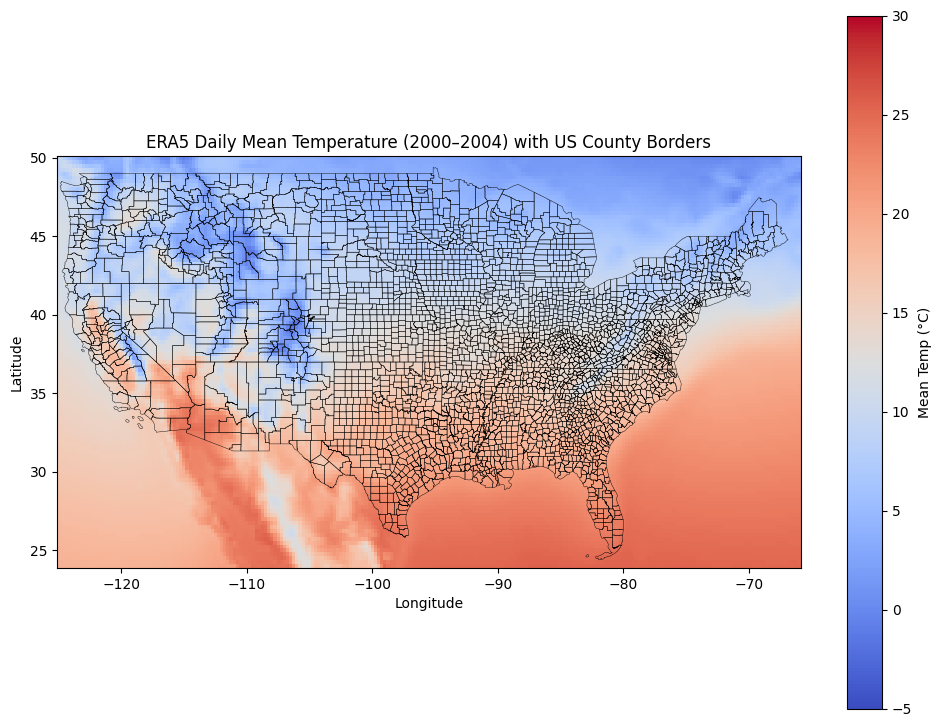

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# Your mainland USA bounding box for counties (in lat/lon)
bbox = box(-125, 24, -66, 50)

# Clip counties to mainland USA
counties_mainland = usa_counties[usa_counties.intersects(bbox)]

# Make sure counties use WGS84 CRS
if counties_mainland.crs != "EPSG:4326":
    counties_mainland = counties_mainland.to_crs("EPSG:4326")

# Clip ERA5 data (assuming mean_temp_celsius is your full DataArray)
# Convert longitudes 0-360 to -180 to 180 for easier plotting with shapefile
mean_temp_celsius.coords['longitude'] = (mean_temp_celsius.coords['longitude'] + 180) % 360 - 180
mean_temp_celsius = mean_temp_celsius.sortby('longitude')

# Select mainland USA area
era5_usa = mean_temp_celsius.sel(
    longitude=slice(-125, -66),
    latitude=slice(50, 24)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot ERA5 temperature raster
era5_usa.plot(
    ax=ax,
    cmap='coolwarm',
    cbar_kwargs={'label': 'Mean Temp (°C)'},
    vmin = -5,
    vmax = 30
)

# Plot county boundaries, no fill, black thicker lines for visibility
counties_mainland.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=.3
)

ax.set_title("ERA5 Daily Mean Temperature (2000–2004) with US County Borders")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


In [26]:

# 1. Get unique counties present in era5_filtered
unique_fips = era5_filtered['fips'].dropna().unique().astype(int)

# 2. Filter shapefile counties
filtered_counties = usa_counties[usa_counties['GEOID'].isin(unique_fips)]


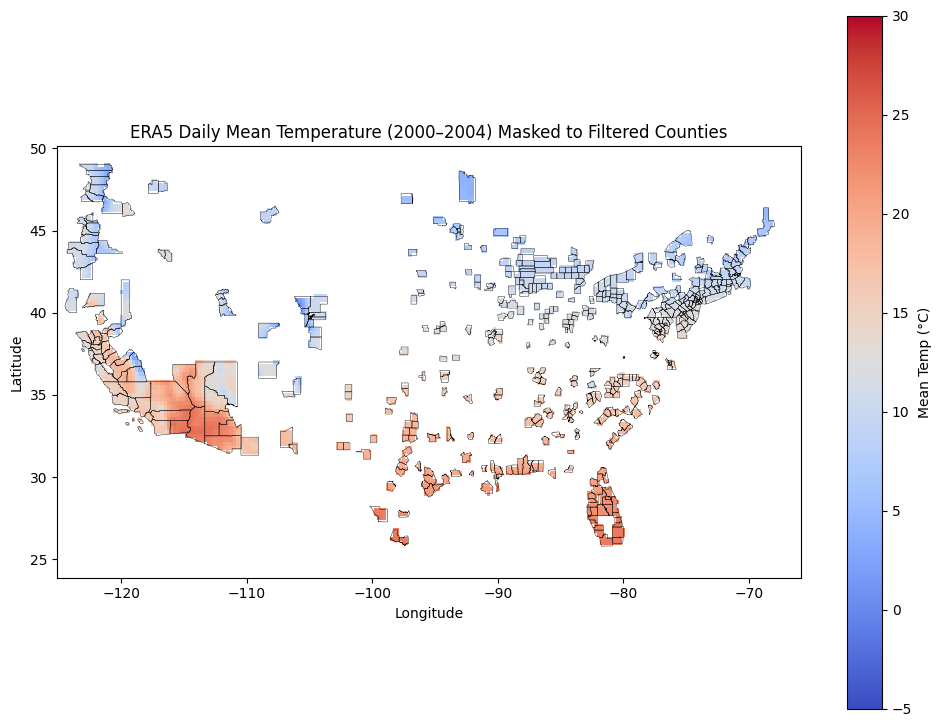

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio.features
import numpy as np
import xarray as xr
from shapely.geometry import box

# Assume filtered_counties GeoDataFrame and mean_temp_celsius DataArray exist

# 1. Prepare mainland USA bounding box
bbox = box(-125, 24, -66, 50)

# 2. Ensure CRS is WGS84 (lat/lon)
if filtered_counties.crs != "EPSG:4326":
    filtered_counties = filtered_counties.to_crs("EPSG:4326")

# 3. Convert ERA5 longitudes 0-360 to -180 to 180 for alignment
mean_temp_celsius.coords['longitude'] = (mean_temp_celsius.coords['longitude'] + 180) % 360 - 180
mean_temp_celsius = mean_temp_celsius.sortby('longitude')

# 4. Select mainland USA bounding box on ERA5
era5_usa = mean_temp_celsius.sel(
    longitude=slice(-125, -66),
    latitude=slice(50, 24)
)

# 5. Rasterize filtered counties polygons to ERA5 grid
# Create transform for rasterio based on ERA5 lon/lat resolution and extent
lon = era5_usa.longitude.values
lat = era5_usa.latitude.values

# Calculate pixel size
res_lon = np.abs(lon[1] - lon[0])
res_lat = np.abs(lat[1] - lat[0])

from rasterio.transform import from_origin

# Note: longitude starts at min lon, latitude starts at max lat for transform
transform = from_origin(lon.min() - res_lon/2, lat.max() + res_lat/2, res_lon, res_lat)

# Create shapes generator (geometry, value) for rasterization: value=1 inside counties
shapes = ((geom, 1) for geom in filtered_counties.geometry)

# Rasterize to shape of ERA5 grid
mask = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=(len(lat), len(lon)),
    transform=transform,
    fill=0,
    dtype=np.uint8
)

# 6. Convert mask to DataArray with same coords as era5_usa
mask_da = xr.DataArray(mask, coords=[lat, lon], dims=['latitude', 'longitude'])

# 7. Apply mask: set ERA5 values outside counties to NaN
masked_era5 = era5_usa.where(mask_da == 1)

# 8. Plot masked ERA5 raster + filtered county boundaries
fig, ax = plt.subplots(figsize=(12, 9))

masked_era5.plot(
    ax=ax,
    cmap='coolwarm',
    cbar_kwargs={'label': 'Mean Temp (°C)'},
    vmin=-5,
    vmax=30
)

filtered_counties.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=0.3
)

ax.set_title("ERA5 Daily Mean Temperature (2000–2004) Masked to Filtered Counties")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()
